In [4]:
!pip install shap
!pip install gradio

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Base de Dados Fictícia:

* Nome do Dataset: DadosSaude

### Colunas:
* ID_Paciente: Identificador único do paciente
* Idade: Idade do paciente
* Genero: Gênero do paciente (Masculino, Feminino, Outro)
* Pressao_Arterial: Pressão arterial média (mm Hg)
* Nivel_Colesterol: Nível de colesterol (mg/dL)
* IMC: Índice de Massa Corporal
* Diabetes: Diagnóstico de diabetes (Sim, Não)
* Fumante: Se o paciente é fumante (Sim, Não)
* Atividade_Fisica: Nível de atividade física semanal (em horas)
* Medicacao: Uso de medicação para pressão arterial (Sim, Não)

## Agenda:

* Introdução ao Seaborn:

    * Introdução à aprendizagem de máquina supervisionada.
    * Breve apresentação da biblioteca SHAP.
    * Comparação ao gradio.

Importação de Bibliotecas e Carregamento dos Dados:

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

np.random.seed(42)  # Para reprodutibilidade

num_pacientes = 1000

ID_Paciente = range(1, num_pacientes + 1)

# Idade dos Pacientes (Distribuição Normal com média 50 e desvio padrão 15)
Idade = np.random.normal(50, 15, num_pacientes).astype(int)
Idade = np.clip(Idade, 18, 90)  # Limitando as idades entre 18 e 90 anos

# Gênero dos Pacientes (Distribuição Uniforme)
Genero = np.random.choice(['Masculino', 'Feminino', 'Outro'], num_pacientes, p=[0.48, 0.48, 0.04])

# Fumante (Maior probabilidade em idades menores)
Fumante = np.where(Idade < 50,
                   np.random.choice(['Sim', 'Não'], p=[0.4, 0.6], size=num_pacientes),
                   np.random.choice(['Sim', 'Não'], p=[0.2, 0.8], size=num_pacientes))

# Índice de Massa Corporal (IMC) (Maior em pacientes mais velhos)
IMC = np.where(Idade < 40,
               np.random.normal(24, 3, num_pacientes),
               np.random.normal(28, 4, num_pacientes))
IMC = np.clip(IMC, 16, 45)

# Diagnóstico de Diabetes (Mais provável em pacientes com IMC alto)
#Diabetes = np.where((IMC > 30) & (Idade > 50),
#                    np.random.choice(['Sim', 'Não'], p=[0.8, 0.2], size=num_pacientes),
#                    np.random.choice(['Sim', 'Não'], p=[0.2, 0.8], size=num_pacientes))

Diabetes = np.where((IMC > 30) & (Idade > 50),
                    np.random.choice(['Sim', 'Não'], p=[0.8, 0.2], size=num_pacientes),
                    np.where((Fumante == 'Sim'),
                             np.random.choice(['Sim', 'Não'], p=[0.95, 0.05], size=num_pacientes),
                             np.random.choice(['Sim', 'Não'], p=[0.2, 0.8], size=num_pacientes)))

# Pressão Arterial (Relacionado à Idade, Fumante e Diabetes)
# Pacientes fumantes e/ou com diabetes têm maior probabilidade de pressão alta
Pressao_Arterial = np.random.normal(120, 10, num_pacientes)
Pressao_Arterial += (Idade / 10)  # Aumento gradual com a idade
Pressao_Arterial += np.where(Fumante == 'Sim', 10, 0)  # Fumantes têm pressão mais alta
Pressao_Arterial += np.where(Diabetes == 'Sim', 10, 0)  # Diabéticos têm pressão mais alta
Pressao_Arterial = np.clip(Pressao_Arterial, 80, 200)

# Nível de Colesterol (Mais alto em idades avançadas e com variabilidade maior em fumantes e diabéticos)
Nivel_Colesterol = np.random.normal(180, 20, num_pacientes)  # Base inicial mais baixa
Nivel_Colesterol += (Idade * 0.5)  # Aumento mais significativo com a idade
Nivel_Colesterol += np.where(Fumante == 'Sim', 30, 0)  # Fumantes têm colesterol mais alto
Nivel_Colesterol += np.where(Diabetes == 'Sim', 40, 0)  # Diabéticos têm colesterol mais alto
Nivel_Colesterol -= np.where(Idade <= 35, 25, 0)  # Pessoas mais novas devem ter um nível de colesterol mais baixo
Nivel_Colesterol = np.clip(Nivel_Colesterol, 100, 350)

# Nível de Atividade Física (Em horas por semana) (Menor em pacientes mais velhos)
Atividade_Fisica = np.where(Idade < 50,
                            np.random.normal(4, 2, num_pacientes),
                            np.random.normal(2, 1.5, num_pacientes))
Atividade_Fisica -= np.where(Fumante == 'Sim', 1, 0)  # Fumantes praticam menos atividades físicas
Atividade_Fisica -= np.where(Diabetes == 'Sim', 3.5, 0)  # Fumantes praticam menos atividades físicas
Atividade_Fisica = np.clip(Atividade_Fisica, 0, 10)

#ajustes com base na atividade física
Pressao_Arterial += np.where(Atividade_Fisica < 2, 20, 0)  # Quem não pratica atividade física têm pressão mais alta
Pressao_Arterial = np.clip(Pressao_Arterial, 80, 200)

Nivel_Colesterol += np.where(Atividade_Fisica < 1, 30, 0)  # Quem não pratica atividade física têm Nivel_Colesterol alto
Nivel_Colesterol += np.where((Atividade_Fisica >= 1) & (Atividade_Fisica < 3), 20, 0)  # Quem pratica atividade física entre 1 e 3 horas tem aumento de 20 no Nivel_Colesterol
Nivel_Colesterol = np.clip(Pressao_Arterial, 80, 200)

# Uso de medicação para pressão arterial (Mais comum em pacientes mais velhos e com pressão alta)
Medicacao = np.where(Pressao_Arterial > 140,
                     np.random.choice(['Sim', 'Não'], p=[0.8, 0.2], size=num_pacientes),
                     np.random.choice(['Sim', 'Não'], p=[0.2, 0.8], size=num_pacientes))

# Criação do DataFrame com os dados gerados
dados = {
    'ID_Paciente': ID_Paciente,
    'Idade': Idade,
    'Genero': Genero,
    'Pressao_Arterial': Pressao_Arterial,
    'Nivel_Colesterol': Nivel_Colesterol,
    'IMC': IMC,
    'Diabetes': Diabetes,
    'Fumante': Fumante,
    'Atividade_Fisica': Atividade_Fisica,
    'Medicacao': Medicacao,
}

df = pd.DataFrame(dados)
df.head()

,ID_Paciente,Idade,Genero,Pressao_Arterial,Nivel_Colesterol,IMC,Diabetes,Fumante,Atividade_Fisica,Medicacao
0,1,57,Masculino,127.634064,127.634064,29.297361,Não,Não,4.370510,Não
1,2,47,Masculino,165.296919,165.296919,25.869098,Sim,Sim,0.000000,Sim
2,3,59,Feminino,126.961829,126.961829,31.358655,Não,Não,3.586141,Não
3,4,72,Feminino,140.821913,140.821913,22.569930,Não,Não,1.878777,Sim
4,5,46,Masculino,144.021634,144.021634,24.397314,Não,Não,0.870052,Sim


In [6]:
df.groupby('Diabetes').describe().T

Diabetes                        Não         Sim
ID_Paciente      count   513.000000  487.000000
                 mean    508.083821  492.511294
                 std     292.406540  285.074006
                 min       1.000000    2.000000
                 25%     245.000000  254.500000
                 50%     513.000000  482.000000
                 75%     761.000000  738.000000
                 max    1000.000000  995.000000
Idade            count   513.000000  487.000000
                 mean     49.847953   49.815195
                 std      14.486938   14.453086
                 min      18.000000   18.000000
                 25%      40.000000   39.000000
                 50%      50.000000   50.000000
                 75%      59.000000   59.000000
                 max      90.000000   90.000000
Pressao_Arterial count   513.000000  487.000000
                 mean    132.746241  160.233507
                 std      14.784812   12.562619
                 min      92.414853  118.933445
                 25%     122.035193  152.271867
                 50%     132.012111  160.011232
                 75%     142.682762  168.547413
                 max     171.983288  198.573829
Nivel_Colesterol count   513.000000  487.000000
                 mean    132.746241  160.233507
                 std      14.784812   12.562619
                 min      92.414853  118.933445
                 25%     122.035193  152.271867
                 50%     132.012111  160.011232
                 75%     142.682762  168.547413
                 max     171.983288  198.573829
IMC              count   513.000000  487.000000
                 mean     26.426600   27.449167
                 std       3.674680    4.445953
                 min      16.000000   16.000000
                 25%      23.820522   24.327623
                 50%      26.360795   27.748515
                 75%      28.954220   30.822373
                 max      40.451641   40.307441
Atividade_Fisica count   513.000000  487.000000
                 mean      2.891813    0.336488
                 std       1.912263    0.782151
                 min       0.000000    0.000000
                 25%       1.438066    0.000000
                 50%       2.657970    0.000000
                 75%       4.233324    0.025543
                 max       9.264772    4.506344

In [7]:
# Mapeamento para smoking_status
Fumante_mapping = {
    'Não': 0,
    'Sim': 1
}

Medicacao_mapping = {
    'Não': 0,
    'Sim': 1
}

Diabetes_mapping = {
    'Não': 0,
    'Sim': 1
}

Genero_mapping = {
    'Feminino': 0,
    'Outro': 1,
    'Masculino':2
}

# Aplicar o mapeamento
df['Medicacao'] = df['Medicacao'].map(Medicacao_mapping)
df['Fumante'] = df['Fumante'].map(Fumante_mapping)
df['Diabetes'] = df['Diabetes'].map(Diabetes_mapping)
df['Genero'] = df['Genero'].map(Genero_mapping)

In [8]:
df.head()

,ID_Paciente,Idade,Genero,Pressao_Arterial,Nivel_Colesterol,IMC,Diabetes,Fumante,Atividade_Fisica,Medicacao
0,1,57,2,127.634064,127.634064,29.297361,0,0,4.370510,0
1,2,47,2,165.296919,165.296919,25.869098,1,1,0.000000,1
2,3,59,0,126.961829,126.961829,31.358655,0,0,3.586141,0
3,4,72,0,140.821913,140.821913,22.569930,0,0,1.878777,1
4,5,46,2,144.021634,144.021634,24.397314,0,0,0.870052,1


In [9]:
df = df.drop(['Medicacao', 'ID_Paciente'], axis=1)
df.head()

,Idade,Genero,Pressao_Arterial,Nivel_Colesterol,IMC,Diabetes,Fumante,Atividade_Fisica
0,57,2,127.634064,127.634064,29.297361,0,0,4.370510
1,47,2,165.296919,165.296919,25.869098,1,1,0.000000
2,59,0,126.961829,126.961829,31.358655,0,0,3.586141
3,72,0,140.821913,140.821913,22.569930,0,0,1.878777
4,46,2,144.021634,144.021634,24.397314,0,0,0.870052


In [10]:
# Separando características e rótulo
X = df.drop(columns=['Diabetes'])
y = df['Diabetes']

In [11]:
from sklearn.ensemble import RandomForestClassifier

In [12]:
from sklearn.model_selection import train_test_split

# Dividindo os dados em treino e teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

clf = RandomForestClassifier(n_estimators=50, random_state=42)

clf.fit(X_train, y_train)

# Avaliando o modelo
y_pred = clf.predict(X_test)

In [13]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

accuracy = accuracy_score(y_test, y_pred)
print("Acurácia:", accuracy)

# Gerando o relatório de classificação
report = classification_report(y_test, y_pred)
print("Relatório de Classificação")
print(report)

Acurácia: 0.905
Relatório de Classificação
              precision    recall  f1-score   support

           0       0.90      0.91      0.91       100
           1       0.91      0.90      0.90       100

    accuracy                           0.91       200
   macro avg       0.91      0.91      0.90       200
weighted avg       0.91      0.91      0.90       200



In [14]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, roc_curve, auc

%matplotlib inline

# Função para plotar a matriz de confusão
def plot_confusion_matrix(y_test, y_pred, target_names):
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=target_names)
    disp.plot(cmap=plt.cm.Blues)
    plt.title('Matriz de Confusão')
    plt.show()

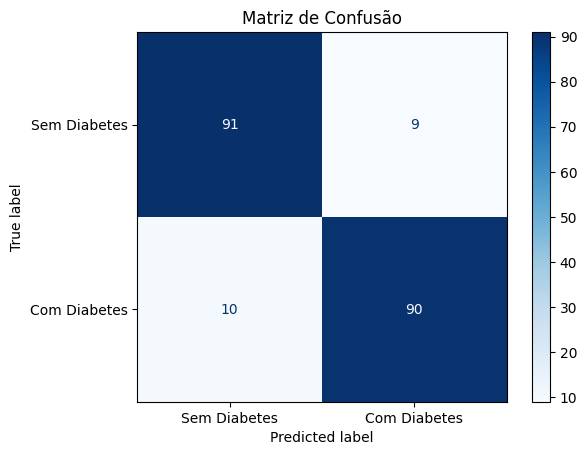

In [15]:
# Plotando a matriz de confusão
plot_confusion_matrix(y_test, y_pred, target_names=["Sem Diabetes", "Com Diabetes"])

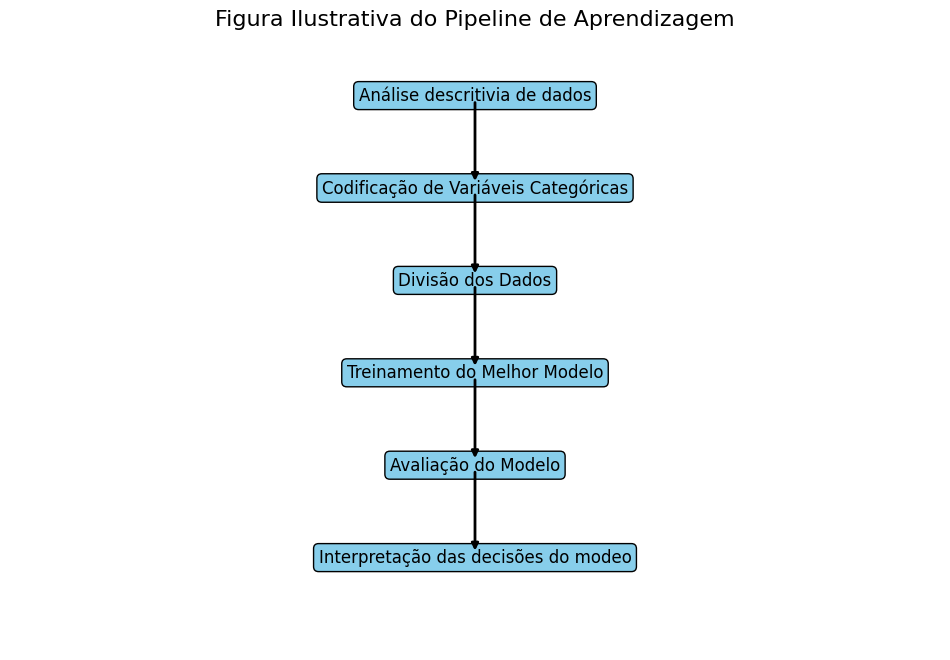

In [16]:
import matplotlib.pyplot as plt

def plot_pipeline():
    fig, ax = plt.subplots(figsize=(12, 8))

    # Lista de etapas do pipeline e suas posições
    steps = [
        ("Análise descritivia de dados", (0.5, 0.9)),
        ("Codificação de Variáveis Categóricas", (0.5, 0.75)),
        ("Divisão dos Dados", (0.5, 0.6)),
        ("Treinamento do Melhor Modelo", (0.5, 0.45)),
        ("Avaliação do Modelo", (0.5, 0.3)),
        ("Interpretação das decisões do modeo", (0.5, 0.15)),
    ]

    # Desenhar retângulos e texto para cada etapa
    for step, (x, y) in steps:
        ax.text(x, y, step, ha='center', va='center', fontsize=12, bbox=dict(boxstyle="round,pad=0.3", edgecolor="black", facecolor="skyblue"))

    # Desenhar setas para conectar as etapas
    arrow_props = dict(facecolor='black', edgecolor='black', shrinkA=5, shrinkB=5, arrowstyle='-|>', lw=2)
    for i in range(len(steps) - 1):
        start = steps[i][1]
        end = steps[i + 1][1]
        ax.annotate('', xy=end, xytext=start, arrowprops=arrow_props)

    # Configurações finais do gráfico
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis('off')  # Desliga os eixos

    plt.title("Figura Ilustrativa do Pipeline de Aprendizagem", fontsize=16)
    plt.show()

plot_pipeline()


## Interpretação de Modelos Preditivos

## Árvore de Decisão

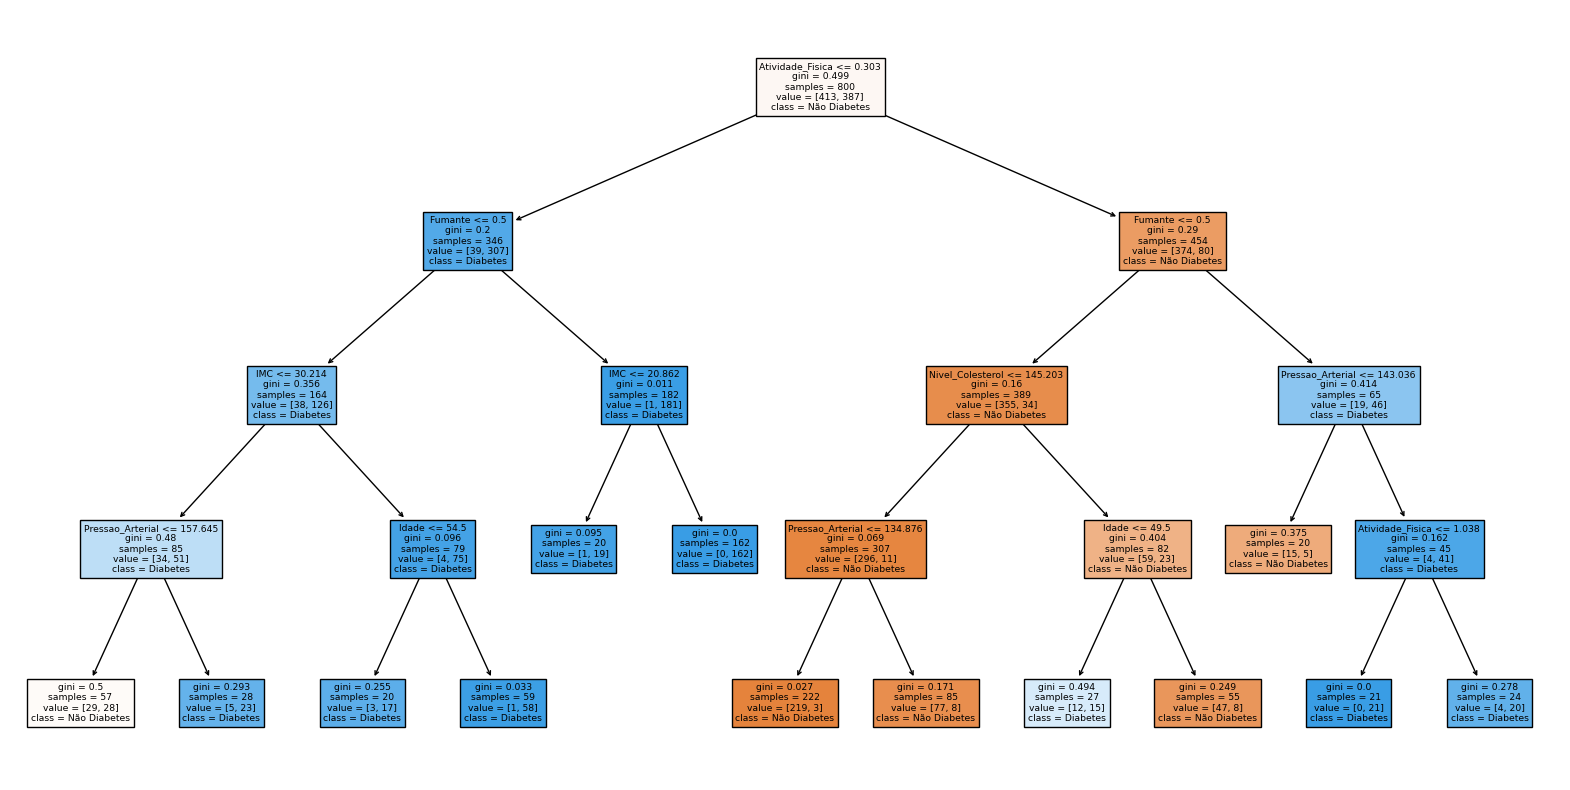

In [17]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt

# Dividindo os dados em treino e teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Usando uma árvore de decisão
dt = DecisionTreeClassifier(
    max_depth=4,               # Limita a profundidade da árvore a 5 níveis
    min_samples_split=20,      # Exige no mínimo 10 amostras para dividir um nó
    min_samples_leaf=20,        # Exige no mínimo 5 amostras em um nó folha
    max_leaf_nodes=20,         # Limita o número máximo de nós folha a 20
    random_state=42
)

# Treinando a árvore de decisão
dt.fit(X_train, y_train)

# Avaliando o modelo
y_pred = dt.predict(X_test)

# Visualizando a árvore de decisão
plt.figure(figsize=(20, 10))  # Define o tamanho da figura
plot_tree(dt, filled=True, feature_names=X.columns, class_names=['Não Diabetes', 'Diabetes'])
plt.show()

In [18]:
!pip install graphviz pydotplus

In [19]:
from sklearn.tree import export_graphviz
import graphviz
import pydotplus

# Exporta a árvore para o formato DOT
dot_data = export_graphviz(
    dt,
    out_file=None,
    filled=True,
    rounded=True,
    special_characters=True,
    feature_names=X.columns,
    class_names=True
)

# Use o pydotplus para converter o arquivo DOT em uma imagem
graph = pydotplus.graph_from_dot_data(dot_data)

# Salva a árvore como SVG
graph.write_svg("decision_tree.svg")

True

In [20]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

accuracy = accuracy_score(y_test, y_pred)
print("Acurácia:", accuracy)

# Gerando o relatório de classificação
report = classification_report(y_test, y_pred)
print("Relatório de Classificação")
print(report)

Acurácia: 0.905
Relatório de Classificação
              precision    recall  f1-score   support

           0       0.85      0.98      0.91       100
           1       0.98      0.83      0.90       100

    accuracy                           0.91       200
   macro avg       0.91      0.91      0.90       200
weighted avg       0.91      0.91      0.90       200



## Shap

In [21]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.datasets import load_breast_cancer
from shap import TreeExplainer, Explanation
from shap.plots import waterfall
import matplotlib.pyplot as plt

import shap
print(shap.__version__)

0.46.0


In [22]:
df.columns

Index(['Idade', 'Genero', 'Pressao_Arterial', 'Nivel_Colesterol', 'IMC',
       'Diabetes', 'Fumante', 'Atividade_Fisica'],
      dtype='object')

In [23]:
df_train = pd.DataFrame(X_train, columns=df.drop(columns=['Diabetes']).columns)
df_train['Diabetes'] = y_train

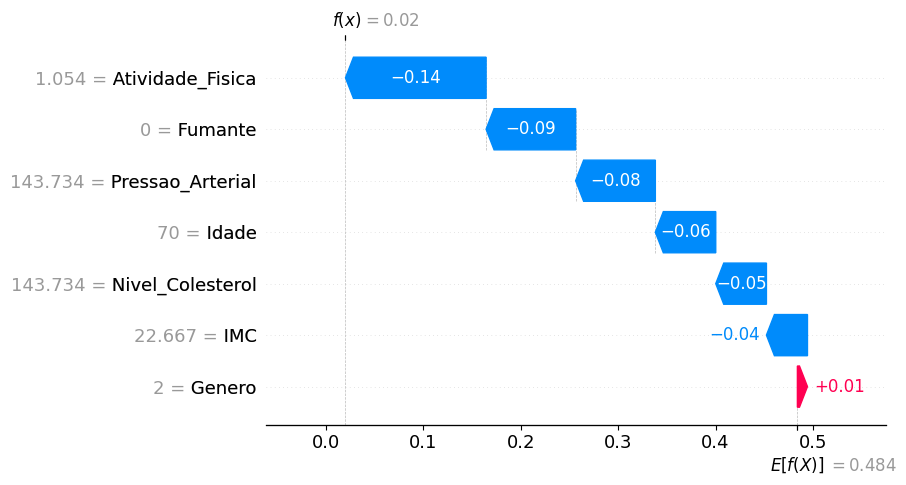

In [24]:
explainer = TreeExplainer(clf)
sv = explainer(X_train)
exp = Explanation(sv.values[:,:,1],
                  sv.base_values[:,1],
                  data=X_train,
                  feature_names= df_train.drop('Diabetes', axis=1).columns)
idx = 10
waterfall(exp[idx])

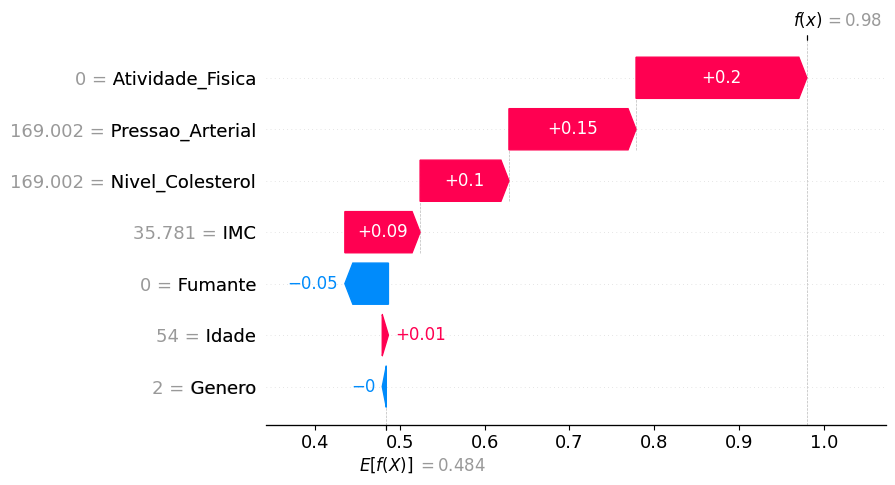

In [25]:
idx = 370
waterfall(exp[idx])

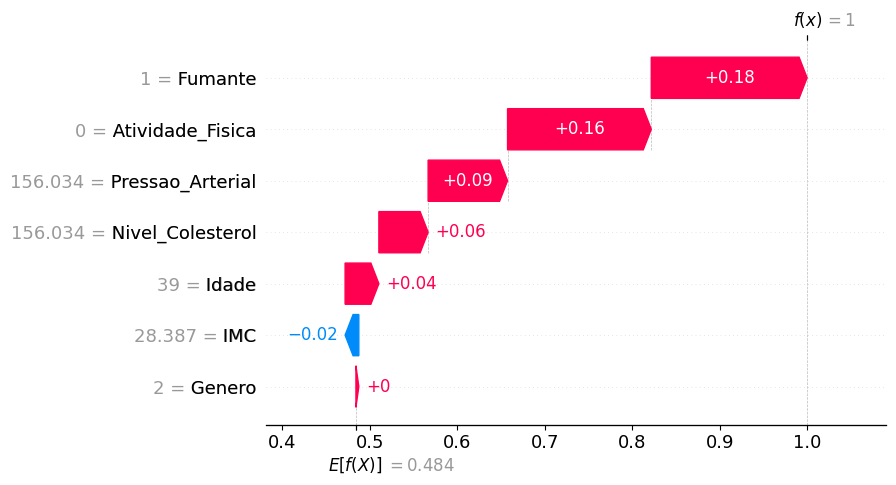

In [26]:
idx = 16
waterfall(exp[idx])

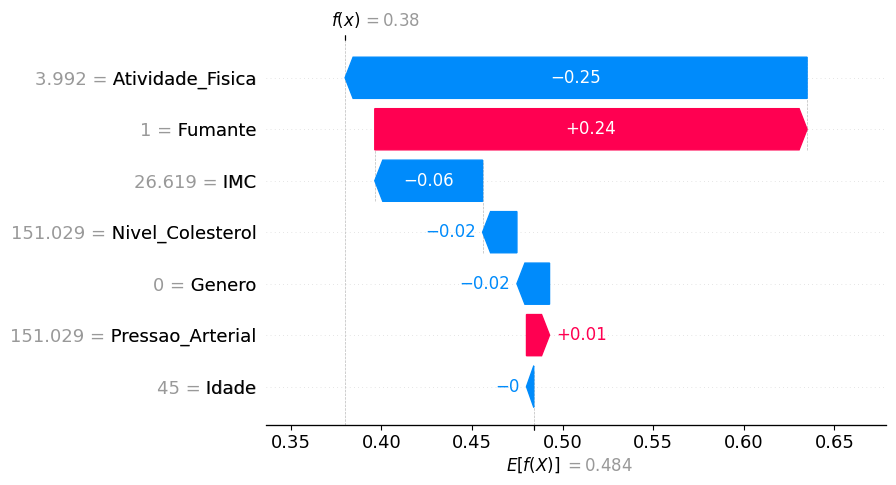

In [27]:
idx = -12
waterfall(exp[idx])

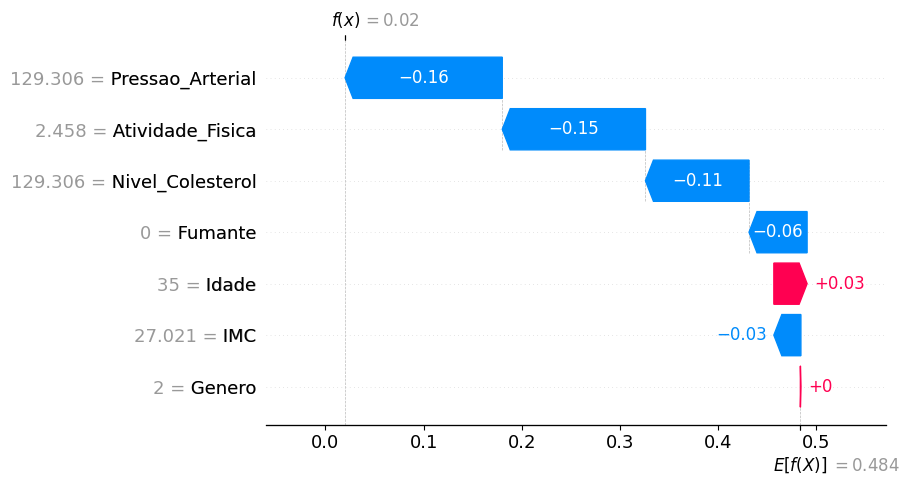

In [28]:
idx = -80
waterfall(exp[idx])

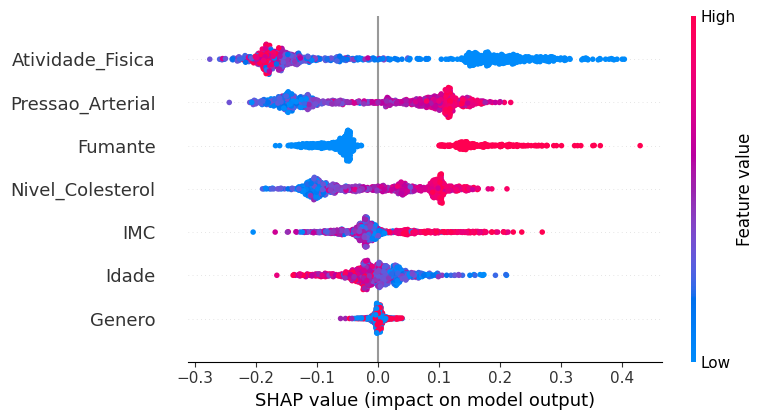

In [29]:
shap.summary_plot(sv.values[:,:,1], X_train, feature_names=df_train.drop('Diabetes', axis=1).columns)

## Gerando Recomendações

In [30]:
!pip install -q -U google-generativeai

In [31]:
import google.generativeai as genai

In [32]:
from google.colab import userdata

In [33]:
GOOGLE_API_KEY=userdata.get('GOOGLE_API_KEY')

genai.configure(api_key=GOOGLE_API_KEY)

In [34]:
model = genai.GenerativeModel('gemini-1.5-flash-latest')

In [35]:
df.drop(columns=['Diabetes']).columns

Index(['Idade', 'Genero', 'Pressao_Arterial', 'Nivel_Colesterol', 'IMC',
       'Fumante', 'Atividade_Fisica'],
      dtype='object')

* Teste de predição

In [36]:
feature_names = df.drop('Diabetes', axis=1).columns.to_list()
input_data = [[12, 0, 120, 120, 30, 1, 0]]

input_df = pd.DataFrame(input_data, columns=feature_names)

r = clf.predict_proba(input_df)[:, 1]
print(r[0] * 100)

64.0


In [37]:
# Exemplo de função de recomendação (substitua pela sua lógica real)
def generate_recommendations(input_data, prediction_percentage):
    #Idade, Genero, Pressao_Arterial, Nivel_Colesterol, IMC, Fumante, Atividade_Fisica
    prompt_gemini = f"""
    #Tarefa
    Gerar recomendações para um paciente com base nos dados dele.

    Paciente com {prediction_percentage:.2f}% chance de ter diabetes.
    Dados do paciente:
    Idade: {input_data[0][0]}
    Gênero: {'Feminino' if input_data[0][1] == 0 else 'Masculino'}
    Pressão arterial (mmHg): {input_data[0][2]}
    Nivel Colesterol (mg/dL): {input_data[0][3]}
    IMC: {input_data[0][4]}
    Stutus de Fumante: {'Fumante' if input_data[0][5] == 1 else 'Não Fumante'}
    Atividade_Fisica (horas por semana): {input_data[0][6]}
    """
    '''
    if prediction_percentage >= 50:
        return "Recomendação: Consulte um médico urgentemente para uma avaliação detalhada.."
    else:
        return "Recomendação: Continue monitorando sua saúde regularmente."
    '''

    print(prompt_gemini)

    response = model.generate_content(prompt_gemini,
                                  generation_config=genai.types.GenerationConfig(
                                    candidate_count=1,
                                    temperature=0.5)
                                  )
    return response.text

In [38]:
# Função de predição e recomendação
def predict_and_recommend(Idade, Genero, Pressao_Arterial, Nivel_Colesterol, IMC, Fumante, Atividade_Fisica):
    # Mapeamento das variáveis categóricas


    Fumante_mapping = {
    'Não': 0,
    'Sim': 1
    }

    Genero_mapping = {
        'Feminino': 0,
        'Outro': 1,
        'Masculino':2
    }

    # Aplicar o mapeamento
    Fumante = Fumante_mapping.get(Fumante, 0)  # Default para Female se valor não mapeado
    Genero = Genero_mapping.get(Genero, 0)  # Default para Female se valor não mapeado

    # Construir vetor de entrada para predição
    feature_names = df.drop('Diabetes', axis=1).columns.to_list()
    input_data = [[Idade, Genero, Pressao_Arterial, Nivel_Colesterol, IMC, Fumante, Atividade_Fisica]]
    input_df = pd.DataFrame(input_data, columns=feature_names)

    # Realizar predição
    prediction = clf.predict_proba(input_df)[:, 1]  # Probabilidade de Diabetes

    # Converter predição para porcentagem
    prediction_percentage = prediction[0] * 100

    # Gerar recomendações com base na predição (substitua esta função pela sua lógica de recomendação)
    recommendation = generate_recommendations(input_data, prediction_percentage)
    print(recommendation)

    return f'{prediction_percentage:.2f}%', recommendation

In [39]:
predict_and_recommend(Idade = 19, Genero = "Feminino", Pressao_Arterial = 130, Nivel_Colesterol  = 130, IMC = 20, Fumante = 'Não', Atividade_Fisica = 8)


    #Tarefa
    Gerar recomendações para um paciente com base nos dados dele.

    Paciente com 8.00% chance de ter diabetes.
    Dados do paciente:
    Idade: 19
    Gênero: Feminino
    Pressão arterial (mmHg): 130
    Nivel Colesterol (mg/dL): 130
    IMC: 20
    Stutus de Fumante: Não Fumante
    Atividade_Fisica (horas por semana): 8
    
## Recomendações para o Paciente:

**Considerando o risco de 8% de diabetes, idade e estilo de vida, as seguintes recomendações são sugeridas:**

**1. Monitoramento:**

* **Exames de sangue periódicos:** Realizar exames de sangue para monitorar os níveis de glicose, hemoglobina glicada (A1c) e outros indicadores de saúde, como colesterol e triglicérides, com frequência recomendada pelo médico.
* **Monitoramento da pressão arterial:** Manter o controle da pressão arterial, buscando manter os níveis dentro da faixa normal. 
* **Monitoramento do peso:** Manter o IMC dentro da faixa saudável, buscando hábitos alimentares saudáveis e atividades físic

('8.00%',
 '## Recomendações para o Paciente:\n\n**Considerando o risco de 8% de diabetes, idade e estilo de vida, as seguintes recomendações são sugeridas:**\n\n**1. Monitoramento:**\n\n* **Exames de sangue periódicos:** Realizar exames de sangue para monitorar os níveis de glicose, hemoglobina glicada (A1c) e outros indicadores de saúde, como colesterol e triglicérides, com frequência recomendada pelo médico.\n* **Monitoramento da pressão arterial:** Manter o controle da pressão arterial, buscando manter os níveis dentro da faixa normal. \n* **Monitoramento do peso:** Manter o IMC dentro da faixa saudável, buscando hábitos alimentares saudáveis e atividades físicas regulares.\n\n**2. Estilo de Vida:**\n\n* **Dieta equilibrada:** Adotar uma dieta rica em frutas, legumes, verduras e proteínas magras, com baixo teor de gorduras saturadas e açucarados. \n* **Atividade física regular:** Manter a prática de 8 horas de atividades físicas semanais, buscando atividades prazerosas e que promov

In [40]:
import gradio as gr
# Interface Gradio
#Idade, Genero, Pressao_Arterial, Nivel_Colesterol, IMC, Fumante, Atividade_Fisica
iface = gr.Interface(
    fn=predict_and_recommend,
    inputs=[
        gr.Slider(0, 100, step=1, label='Idade'),
        gr.Radio(['Masculino', 'Feminino'], label='Gênero'),
        gr.Slider(0, 300, step=0.1, label='Pressão Arterial'),
        gr.Slider(0, 300, step=0.1, label='Nivel Colesterol'),
        gr.Slider(4, 50, step=0.1, label='IMC'),
        gr.Radio(['Sim', 'Não'], label='Fumante'),
        gr.Slider(0, 40, step=0.1, label='Atividade Física (horas por semana)'),
    ],
    outputs=[
        gr.Textbox(label='Probabilidade de Diabetes'),
        gr.Textbox(label='Recomendações')
    ],
    title="Predição e Recomendações relacionadas a Diabetes",
    description="Inferir a probabilidade de Diabetes e obtenha recomendações com base nos dados do paciente."
)

iface.launch(debug=True)

Setting queue=True in a Colab notebook requires sharing enabled. Setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
Running on public URL: https://53e66ec5544c34a0c2.gradio.live

This share link expires in 72 hours. For free permanent hosting and GPU upgrades, run `gradio deploy` from Terminal to deploy to Spaces (https://huggingface.co/spaces)



    #Tarefa
    Gerar recomendações para um paciente com base nos dados dele.

    Paciente com 0.00% chance de ter diabetes.
    Dados do paciente:
    Idade: 23
    Gênero: Masculino
    Pressão arterial (mmHg): 0
    Nivel Colesterol (mg/dL): 0
    IMC: 28.4
    Stutus de Fumante: Não Fumante
    Atividade_Fisica (horas por semana): 10
    
## Recomendações para o Paciente:

**Parabéns!** Com base nos seus dados, você tem **0.00% de chance de ter diabetes**, o que é ótimo! 

No entanto, alguns dos seus dados precisam ser revisados para que possamos te ajudar de forma mais completa:

* **Pressão Arterial:** 0 mmHg é um valor impossivelmente baixo. Por favor, verifique a informação e informe a sua pressão arterial real.
* **Nível de Colesterol:** 0 mg/dL também é um valor impossível. Por favor, informe o seu nível de colesterol real.

**Considerando os dados informados:**

* **IMC:** 28.4 está dentro da faixa de sobrepeso. É importante manter um peso saudável para prevenir doenças co

## Atividade

1. Ajuste o código, gerando gráficos para novas instâncias no SHAP.
2. Alterando o prompt do Gemini para gerar recomendações diferentes.
3. Faça seu cadastro no Kaggle, busque uma base de dados relacionada à saúde e adapte o código desta aula na usa base de dados. Exemplo de base de dados que pode ser utilizada:
* https://www.kaggle.com/datasets/fedesoriano/stroke-prediction-dataset
* https://www.kaggle.com/datasets/jillanisofttech/brain-stroke-dataset
* https://www.kaggle.com/datasets/mazharkarimi/heart-disease-and-stroke-prevention
* https://www.kaggle.com/datasets/lirilkumaramal/heart-stroke
* https://www.kaggle.com/datasets/amirhashemi1999/diabities-prediction/code
* https://www.kaggle.com/datasets/mahmoudhassanmahmoud/diabites-dataset

**A atividade pode ser feita em grupo de até 3 estudantes. Envio um relatório num editor de texto ou no próprio collab.**

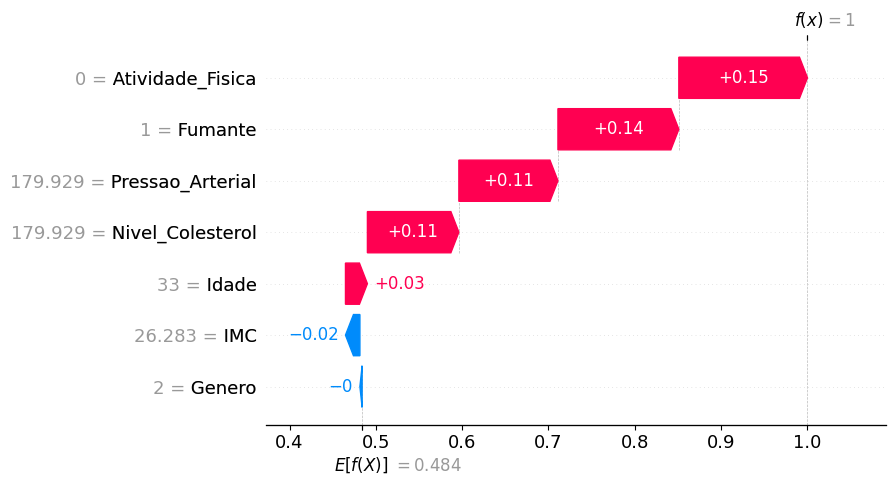

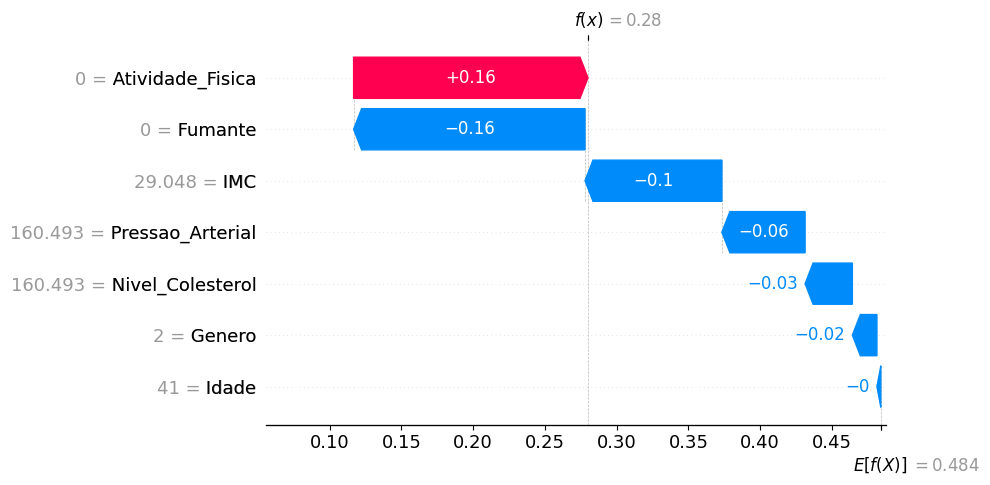

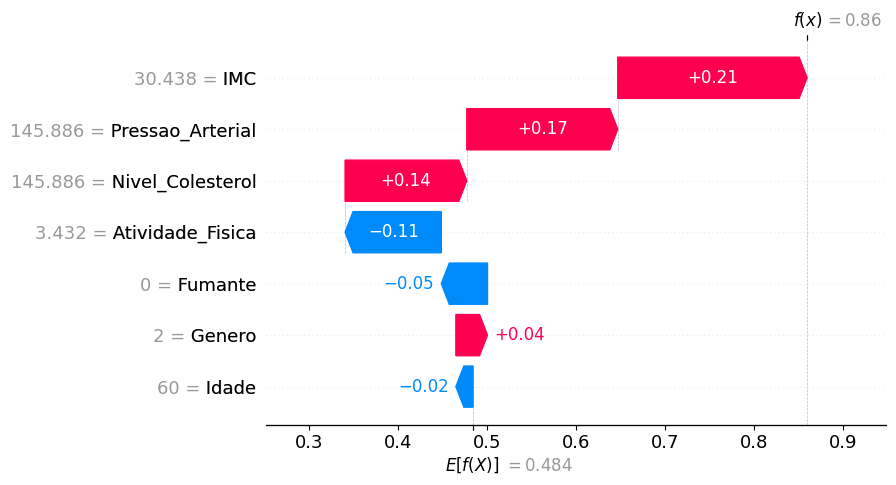

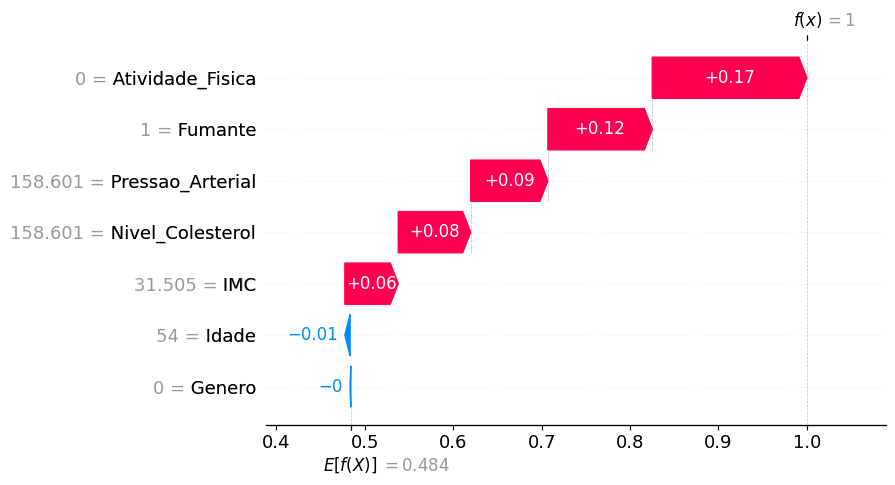

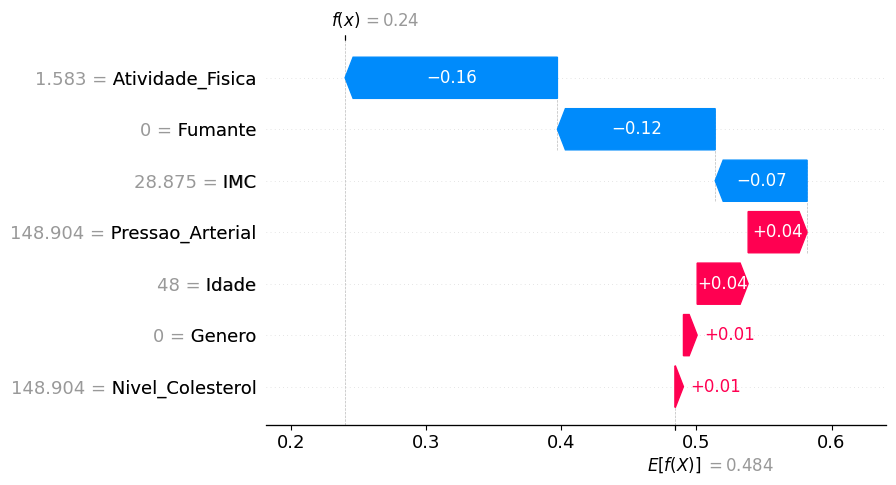

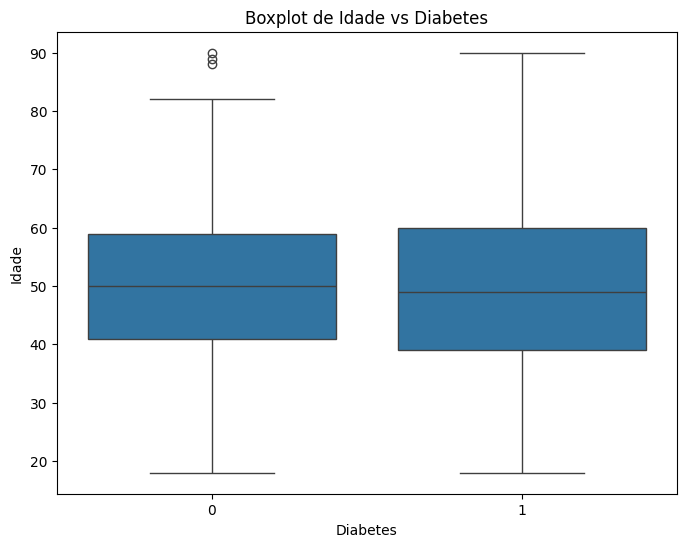

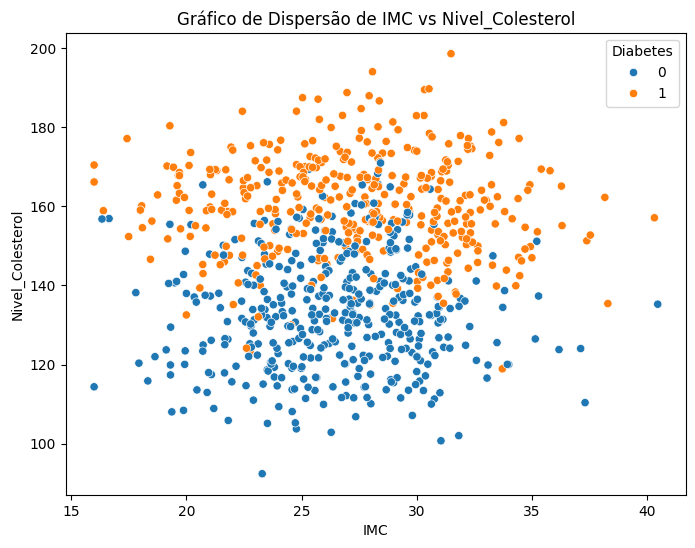

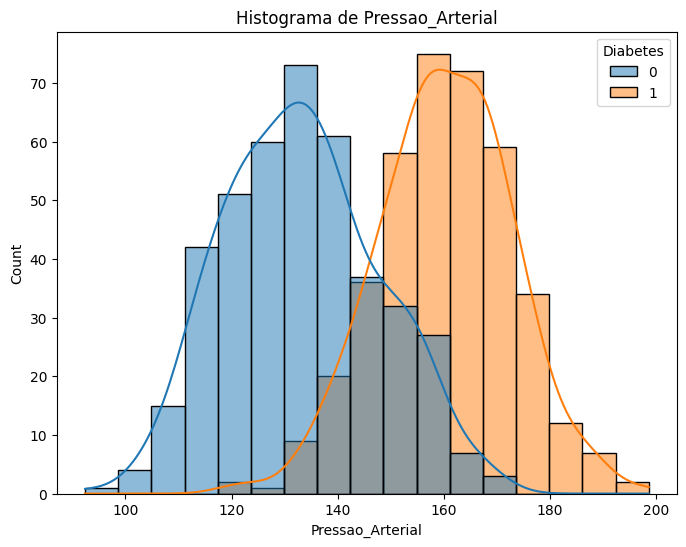

In [41]:
import matplotlib.pyplot as plt
# ... (código anterior)

# Gerando gráficos para novas instâncias no SHAP
for idx in [100, 200, 300, 400, 500]:  # Escolha alguns índices para gerar os gráficos
  waterfall(exp[idx])

# Gráficos de estatística descritiva
# Boxplot para Idade vs Diabetes
plt.figure(figsize=(8, 6))
sns.boxplot(x='Diabetes', y='Idade', data=df_train)
plt.title('Boxplot de Idade vs Diabetes')
plt.show()

# Gráfico de dispersão para IMC vs Nivel_Colesterol
plt.figure(figsize=(8, 6))
sns.scatterplot(x='IMC', y='Nivel_Colesterol', hue='Diabetes', data=df_train)
plt.title('Gráfico de Dispersão de IMC vs Nivel_Colesterol')
plt.show()

# Histograma para Pressao_Arterial
plt.figure(figsize=(8, 6))
sns.histplot(x='Pressao_Arterial', hue='Diabetes', data=df_train, kde=True)
plt.title('Histograma de Pressao_Arterial')
plt.show()

# ... (código posterior)
